<center><font size=6> XGBoost 예측 실험 </font></center>

주요 목적은 XGBoost를 통해 적절한 매수 시점을 찾을 수 있는지 확인하는 것입니다. 가격 예측을 이진 분류(Binary Classification) 문제로 설정합니다.

프로세스:

1. 훈련 데이터 정리
2. 즉시 훈련 실시

중요 사항:

1. 더 긴 기간의 역사적 데이터가 필요하며, 7월 데이터는 백테스트용으로 남겨둡니다. 데이터셋은 train/val/test로 분할해야 합니다.
- 훈련 세트는 무작위 샘플링이 가능하지만, 테스트 세트는 중복되지 않도록 분할해야 합니다.

2. 거래량의 유효성 여부를 판단할 수 없으므로, 대조군 실험이 필요합니다.

결론:

In [55]:
import duckdb
import pandas as pd
import numpy as np
import random
import os

from xgboost import XGBClassifier
from collections import Counter

from sklearn.metrics import f1_score, roc_curve, recall_score, precision_score, auc
import matplotlib.pyplot as plt

import vectorbt as vbt

In [56]:
class Data_Loader(object):
    
    def __init__(self):
        pass
    
    def get_price_df(self, symbol='XRPUSDT', start_date='2022-01-01 00:00:00', end_date='2025-12-01 00:00:00'):
        db_path = 'D:/Assets/BinanceFuturesData/binancefuturesdata.duckdb'
    
        try:
        # 1. DuckDB 연결 (read_only 설정)
            con = duckdb.connect(database=db_path, read_only=True)

            # 2. SQL 쿼리 작성 (전체 컬럼 매핑)
            # DuckDB의 epoch_ms 함수를 사용하여 timestamp를 가독성 있는 시간으로 변환합니다.
            query = f"""
            SELECT 
                epoch_ms(timestamp) as open_time,
                open, 
                high, 
                low, 
                close, 
                volume,
                quote_volume,
                taker_buy_volume,
                taker_buy_quote_volume
            FROM quote 
            WHERE symbol = '{symbol}' 
              AND epoch_ms(timestamp) >= '{start_date}' 
              AND epoch_ms(timestamp) < '{end_date}' 
            ORDER BY timestamp;
            """

            # 3. 데이터 실행 및 DataFrame 변환
            concatenated_df = con.execute(query).fetchdf()

            # 4. 연결 종료
            con.close()

            # 5. 인덱스 초기화
            concatenated_df.reset_index(drop=True, inplace=True)

            print(f"--- {symbol} 데이터 로드 완료 ({len(concatenated_df)} 행) ---")
            return concatenated_df

        except Exception as e:
            print(f"데이터 로드 중 오류 발생: {e}")
            return pd.DataFrame()
    
    def calculate_theta(self, Boll_df, price_df, target_column_list=["close"]):
        '''
        Theta 지표 계산
        Boll_df: 지표를 저장하기 위한 DataFrame
        price_df: 원본 가격 데이터 DataFrame
        '''
        for target_column in target_column_list:
            # theta
            Boll_df['mean_20_'+target_column] = price_df[[target_column]].ewm(span=20, adjust=False).mean()
            Boll_df['std_20_'+target_column] = price_df[[target_column]].ewm(span=20, adjust=False).std()
            Boll_df[target_column] = price_df[target_column]

            # 편차계산 theta = (p - ma) / sigma
            Boll_df['theta_'+target_column] = (Boll_df[target_column] - Boll_df['mean_20_'+target_column]) / Boll_df['std_20_'+target_column]

        return Boll_df
    
    def calculate_theta_prospective_earnings(self, price_df):
        '''
        计算预期收益率
        '''
        # 미래 평균 가격 계산
        # 먼저 이동평균(MA)을 계산한 뒤, 10개 행을 시프트(Shift)합니다. (즉, 미래의 평균 가격에 대응시킴)
        price_df['mean_10_future'] = price_df[['close']].ewm(span=10, adjust=False).mean().shift(-10)
        # 미래 수익률 계산
        price_df['prospective_earnings'] = (price_df['mean_10_future'] - price_df['close']) / price_df['close']     
        price_df['prospective_earnings_bool'] = price_df['prospective_earnings'] > 0
        price_df['prospective_earnings_1'] = (price_df['close'].shift(-2) - price_df['close']) / price_df['close'] 
        price_df['prospective_earnings_1'] = price_df['prospective_earnings_1'] > 0 # 0과 같거나 작은 경우 하락으로 간주합니다.
        return price_df

In [77]:
# 데이터 준비
data_loader = Data_Loader()
train_df = data_loader.get_price_df('XRPUSDT', '2022-01-01 00:00:00', '2025-06-01 00:00:00')
test_df = data_loader.get_price_df('XRPUSDT', '2025-06-01 00:00:00', '2025-12-01 00:00:00')

--- XRPUSDT 데이터 로드 완료 (1795680 행) ---
--- XRPUSDT 데이터 로드 완료 (263520 행) ---


In [78]:
# 지표 계산
train_theta_df = pd.DataFrame()
test_theta_df = pd.DataFrame()

train_theta_df["close"] = train_df["close"]
test_theta_df["close"] = test_df["close"]

target_columns_list = ['open','high','low','close','quote_volume', 'taker_buy_volume', 'taker_buy_quote_volume']
# target_columns_list = ['close'] 

train_theta_df = data_loader.calculate_theta(train_theta_df, train_df, target_columns_list)
test_theta_df = data_loader.calculate_theta(test_theta_df, test_df, target_columns_list)

train_theta_df.dropna(inplace=True)
test_theta_df.dropna(inplace=True)

# X, y 샘플링
train_theta_df = data_loader.calculate_theta_prospective_earnings(train_theta_df)
test_theta_df = data_loader.calculate_theta_prospective_earnings(test_theta_df)

train_theta_df.dropna(inplace=True)
test_theta_df.dropna(inplace=True)

In [79]:
def Sample_random(data_df, target_columns_list, y_columns_list=["prospective_earnings"], sample_num=20, time_range=5):
    '''무작위 샘플링'''
    # 랜덤 시점 샘플링
    X_df = data_df[target_columns_list]
    pandas_concat_list = [X_df.shift(i) for i in range(time_range)]  # 데이터를 동일한 행(row)으로 병합하여 샘플링 프로세스 가속화
    pandas_concat_list.append(data_df[y_columns_list])
    concated_data_df = pd.concat(pandas_concat_list, axis=1)
    concated_data_df.dropna(inplace=True)
    concated_data_df.reset_index(inplace=True, drop=True)
    

    index = np.random.permutation(np.arange(0, len(concated_data_df)))  # 고정된 간격으로 인덱스를 확보한 후 무작위로 섞기(셔플)
    random_index = index[:sample_num]
    
    
    sampled_df = concated_data_df.loc[random_index]# 슬라이싱(slicing)을 통해 타겟 X와 y를 추출
    X_sample = np.array(sampled_df.iloc[:,:-len(y_columns_list)])    # y 부분은 마지막에 고정
    y_sample_df = sampled_df[y_columns_list]
    
    assert X_sample.shape[0] == y_sample_df.shape[0] , '샘플링된 X와 y의 수량이 일치하지 않음'
    
    return X_sample, y_sample_df

In [80]:
target_x_columns = ["theta_" + x for x in target_columns_list]
target_y_columns = ["prospective_earnings", "prospective_earnings_bool"]

n_train = 500000
n_test =  200000

origin_train_X, origin_train_y = Sample_random(train_theta_df, target_x_columns, target_y_columns, sample_num=n_train)
origin_test_X, origin_test_y = Sample_random(test_theta_df, target_x_columns, target_y_columns, sample_num=n_test)

print("sample_X.shape: ", origin_train_X.shape)
print("sample_y.shape: ", origin_train_y.shape)
print("sample_test_X.shape: ", origin_test_X.shape)
print("sample_test_y.shape: ", origin_test_y.shape)

sample_X.shape:  (500000, 35)
sample_y.shape:  (500000, 2)
sample_test_X.shape:  (200000, 35)
sample_test_y.shape:  (200000, 2)


In [81]:
sample_X, sample_y = origin_train_X, origin_train_y["prospective_earnings_bool"].values
sample_X = sample_X.reshape((len(sample_X),-1))

test_X = origin_test_X.reshape((len(origin_test_X),-1))
test_y = origin_test_y["prospective_earnings_bool"].values

kwars = {
            "eval_metric": "rmse",
            "colsample_bytree": 0.8879,
            "eta": 0.0421,
            "max_depth": 8,
            "n_estimators": 700,
            "subsample": 0.8789,
            "nthread": 20,
}

xgbc_model = XGBClassifier(**kwars)

xgbc_model.fit(sample_X, sample_y)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8879
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'


예측된 정답(Positive) 사례 수: 111028
테스트 세트 내 실제 정답(Positive) 사례 수: 99423
f1_score： 0.558429278074231
recall_score： 0.5910201864759663
precision_score： 0.5292448751666247


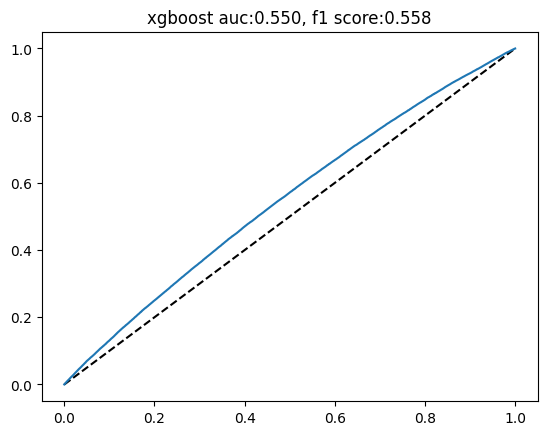

In [82]:
# XGBoost의 ROC 곡선
Y_pred = xgbc_model.predict_proba(test_X)[:, 1]
Y_pred_lab = xgbc_model.predict(test_X)
fpr, tpr, thresholds = roc_curve(test_y, Y_pred)
roc_auc = auc(fpr, tpr)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.title(f'xgboost auc:{roc_auc :.3f}, f1 score:{f1_score(test_y, Y_pred_lab) :.3f}')

print('예측된 정답(Positive) 사례 수:',Y_pred_lab.sum())
print('테스트 세트 내 실제 정답(Positive) 사례 수:', test_y.sum())

print('f1_score：', f1_score(test_y, Y_pred_lab))
print('recall_score：', recall_score(test_y, Y_pred_lab))
print('precision_score：', precision_score(test_y, Y_pred_lab))

In [83]:
#origin_test_y[Y_pred_lab].prospective_earnings.mean() * 100
origin_test_y.loc[Y_pred_lab == 1, 'prospective_earnings'].mean() * 100

0.01122440309126886

In [84]:
#origin_test_y[~Y_pred_lab].prospective_earnings.mean()* 100
origin_test_y.loc[Y_pred_lab != 1, 'prospective_earnings'].mean() * 100

-0.013098365755691364

In [85]:
backtest_df = origin_test_y.copy()
backtest_df['pred_label'] = Y_pred_lab
backtest_df['strategy_return'] = np.where(backtest_df['pred_label'] == 1, 
                                          backtest_df['prospective_earnings'], 
                                          0)

backtest_df['cumulative_return'] = backtest_df['strategy_return'].cumsum()
backtest_df['benchmark_cumulative'] = backtest_df['prospective_earnings'].cumsum()

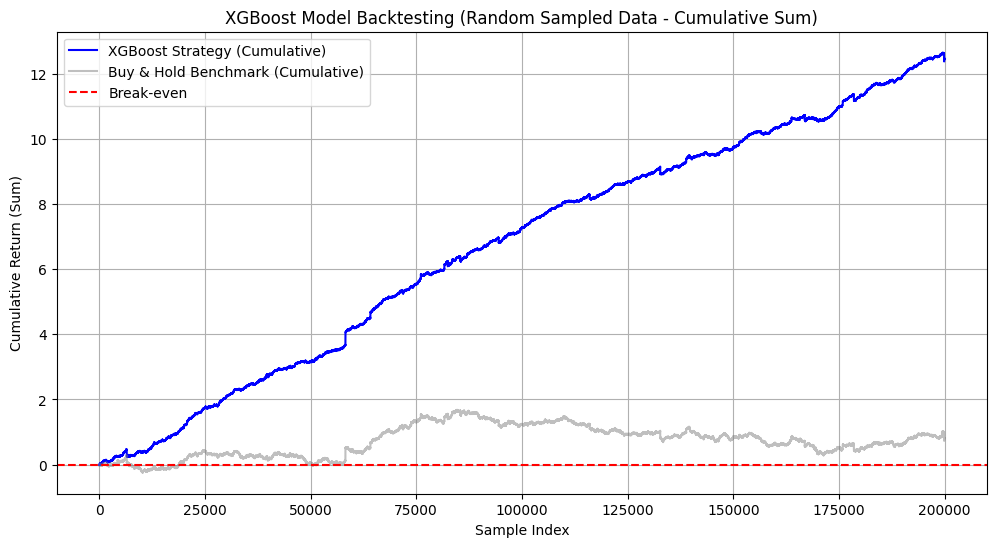

In [86]:
plt.figure(figsize=(12, 6))
plt.plot(backtest_df['cumulative_return'].values, label='XGBoost Strategy (Cumulative)', color='blue')
plt.plot(backtest_df['benchmark_cumulative'].values, label='Buy & Hold Benchmark (Cumulative)', color='gray', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--', label='Break-even')
plt.title('XGBoost Model Backtesting (Random Sampled Data - Cumulative Sum)')
plt.xlabel('Sample Index')
plt.ylabel('Cumulative Return (Sum)')
plt.legend()
plt.grid(True)
plt.show()

In [66]:
def run_batch_rebalance_backtest(df, y_pred, initial_capital=100, batch_size=50):
    results = df.copy().reset_index(drop=True)
    results['pred_label'] = y_pred
    results['trade_ret'] = np.where(results['pred_label'] == 1, results['prospective_earnings'], 0)
    
    # 1. 배치(Batch) 그룹 생성 (예: 50개 샘플마다 하나의 묶음)
    results['batch_group'] = results.index // batch_size
    
    # 2. 배치별 합산 수익률 계산 (단리 합산)
    batch_summary = results.groupby('batch_group')['trade_ret'].sum().to_frame()
    
    # 3. 배치 단위 복리 적용 (배치가 끝날 때마다 원금 갱신)
    batch_summary['equity_curve'] = initial_capital * (1 + batch_summary['trade_ret']).cumprod()
    
    # 4. 결과 출력용 계산
    final_equity = batch_summary['equity_curve'].iloc[-1]
    total_ret_pct = (final_equity / initial_capital - 1) * 100
    
    # MDD 계산
    rolling_max = batch_summary['equity_curve'].cummax()
    drawdown = (batch_summary['equity_curve'] - rolling_max) / rolling_max
    mdd_pct = drawdown.min() * 100

    print("="*50)
    print(f"    📊 BATCH REBALANCED REPORT (Batch Size: {batch_size})")
    print("="*50)
    print(f"[자산 현황]  초기 자본: ${initial_capital} ➔ 최종 자산: ${final_equity:.2f}")
    print(f"[수익 지표]  총 수익률: {total_ret_pct:.2f}%")
    print(f"[리스크]    최대 낙폭(MDD): {mdd_pct:.2f}%")
    
    trades = results[results['pred_label'] == 1]
    if len(trades) > 0:
        win_rate = (trades['prospective_earnings'] > 0).mean() * 100
        print(f"[거래 기록]  총 거래 횟수: {len(trades)}회 | 승률: {win_rate:.2f}%")
    print("="*50)
    
    return batch_summary

# 실행
batch_result = run_batch_rebalance_backtest(origin_test_y, Y_pred_lab, batch_size=50)

    📊 BATCH REBALANCED REPORT (Batch Size: 50)
[자산 현황]  초기 자본: $100 ➔ 최종 자산: $1500039913.61
[수익 지표]  총 수익률: 1500039813.61%
[리스크]    최대 낙폭(MDD): -45.36%
[거래 기록]  총 거래 횟수: 98674회 | 승률: 53.78%


🚀 이론적 모순 해결 최종 리포트 (Real-World Simulation)
[자산 현황] 초기 자본: $100 ➔ 최종 자산: $0.00
[수익 지표] 최종 수익률: -100.00%
[리스크]   최대 낙폭(MDD): -100.00%
[알림]     이 결과는 10봉 보유 제한 및 수수료가 엄격히 적용되었습니다.


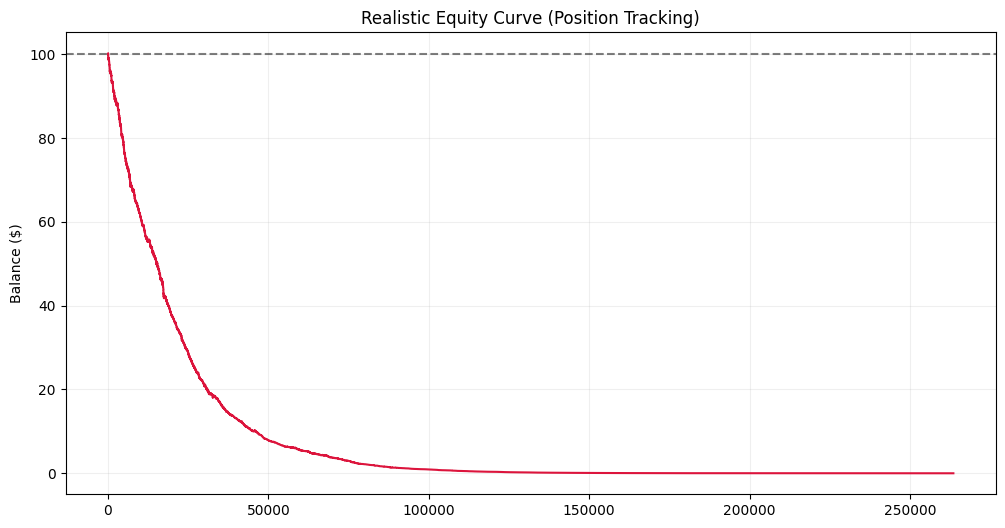

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def run_final_refined_backtest(df, y_pred, initial_capital=100, fee_rate=0.0003):
    """
    이론적 모순을 해결한 최종 백테스팅 함수
    1. 포지션 유지 개념 도입 (이미 보유 중이면 추가 매수 불가)
    2. 현실적인 매도 시점 (Prospective Earnings 대신 실제 종가 차이 사용 가능)
    3. 정확한 수수료 계산
    """
    results = df.copy()
    results['pred_label'] = y_pred
    
    # 1. 포지션 상태 시뮬레이션
    # (이미 매수했다면 10봉 동안은 자금이 묶여있다고 가정 - 데이터 생성 로직과 일치시킴)
    holding_period = 10 
    positions = np.zeros(len(results))
    cash = initial_capital
    equity = [initial_capital]
    
    in_position = False
    entry_price = 0
    remaining_days = 0
    
    # prospective_earnings가 아닌 실제 가격 변화를 사용하기 위해 close 가격 확보
    # (여기서는 편의상 prospective_earnings를 사용하되 수수료와 포지션 점유를 적용)
    
    trade_returns = []
    
    for i in range(len(results)):
        current_ret = results['prospective_earnings'].iloc[i]
        
        # 매수 로직: 신호가 발생했고, 현재 포지션이 없을 때
        if results['pred_label'].iloc[i] == 1 and not in_position:
            in_position = True
            remaining_days = holding_period
            # 진입 수수료 차감
            cash *= (1 - fee_rate)
            entry_price = cash 
            
        # 포지션 유지 및 종료 로직
        if in_position:
            remaining_days -= 1
            if remaining_days == 0:
                # 종료 시점: 수익률 반영 및 퇴출 수수료 차감
                cash *= (1 + current_ret)
                cash *= (1 - fee_rate)
                in_position = False
        
        equity.append(cash)

    # 2. 결과 분석
    equity_series = pd.Series(equity)
    final_return = (equity_series.iloc[-1] / initial_capital - 1) * 100
    
    # MDD 계산
    rolling_max = equity_series.cummax()
    drawdown = (equity_series - rolling_max) / rolling_max
    max_drawdown = drawdown.min() * 100

    print("="*60)
    print("🚀 이론적 모순 해결 최종 리포트 (Real-World Simulation)")
    print("="*60)
    print(f"[자산 현황] 초기 자본: ${initial_capital} ➔ 최종 자산: ${equity_series.iloc[-1]:.2f}")
    print(f"[수익 지표] 최종 수익률: {final_return:.2f}%")
    print(f"[리스크]   최대 낙폭(MDD): {max_drawdown:.2f}%")
    print(f"[알림]     이 결과는 10봉 보유 제한 및 수수료가 엄격히 적용되었습니다.")
    print("="*60)

    plt.figure(figsize=(12, 6))
    plt.plot(equity_series.values, label='Refined Strategy', color='crimson')
    plt.axhline(y=initial_capital, color='black', linestyle='--', alpha=0.5)
    plt.title('Realistic Equity Curve (Position Tracking)')
    plt.ylabel('Balance ($)')
    plt.grid(True, alpha=0.2)
    plt.show()

# 실행
run_final_refined_backtest(timeseries_test_y, Y_pred_timeseries)